In [189]:
from datetime import datetime
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import glob
import matplotlib.image as mpimg

# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)


# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)

# Custom imports
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement

import importlib
import pinns_solution_functions

importlib.reload(pinns_solution_functions)
from pinns_solution_functions import (
    set_seed, generate_points, MLP, init_weights,
    train_adam_with_logs_adaptive, train_lbfgs_with_logs_adaptive,
    predict_displacement_pinns
)
# Seed
set_seed(42)

output_dir = "figs_sampling"
os.makedirs(output_dir, exist_ok=True)

In [190]:
r_i = np.pi / 4
l_e = np.pi
side_length = 2 * l_e
n_grid = 501
k = 3.0

# Base sampling
n_Omega_P = 10_000
n_Gamma_I = 100
n_Gamma_E = 250

# Training
adam_lr = 1e-2
adam_iters = 1_00
lbfgs_iters = 5_00

hidden_layers_ = 3
hidden_units_  = 25

# Grid
Y, X = np.mgrid[-l_e:l_e:n_grid*1j, -l_e:l_e:n_grid*1j]
R_exact = np.sqrt(X**2 + Y**2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Activation
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

activation_function_ = Sine()

In [191]:
# Exact solution
u_inc_exact, u_scn_exact, u_exact = sound_hard_circle_calc(k, r_i, X, Y, n_terms=None)
u_inc_exact = mask_displacement(R_exact, r_i, l_e, u_inc_exact)
u_scn_exact = mask_displacement(R_exact, r_i, l_e, u_scn_exact)
u_exact = mask_displacement(R_exact, r_i, l_e, u_exact)

In [192]:
# -------- Training points --------
x_f, y_f, x_inner, y_inner, x_left, y_left, x_right, y_right, \
x_bottom, y_bottom, x_top, y_top = generate_points(
    n_Omega_P, side_length, r_i, n_Gamma_I, n_Gamma_E
)

In [193]:
# -------- Model --------
model = MLP(
    input_size=2,
    output_size=2,
    hidden_layers=hidden_layers_,
    hidden_units=hidden_units_,
    activation_function=activation_function_
).to(device)

model.apply(init_weights)


MLP(
  (linear_in): Linear(in_features=2, out_features=25, bias=True)
  (linear_out): Linear(in_features=25, out_features=2, bias=True)
  (layers): ModuleList(
    (0-2): 3 x Linear(in_features=25, out_features=25, bias=True)
  )
  (act): Sine()
)

In [ ]:

results = []
iter_train = 0

# -------- Adam --------
iter_train = train_adam_with_logs_adaptive(
    model,
    x_f, y_f,
    x_inner, y_inner,
    x_left, y_left,
    x_right, y_right,
    x_bottom, y_bottom,
    x_top, y_top,
    k,
    iter_train,
    results,
    adam_lr,
    num_iter=adam_iters,
    save_csv_path='data/adaptive_sampling_adam.csv',
    save_csv_path_no_datetime=None,
    l_e=l_e,
    r_i=r_i,
    n_grid=n_grid,
    X=X,
    Y=Y,
    R_exact=R_exact,
    u_scn_exact=u_scn_exact,
    u_exact=u_exact
)

# -------- L-BFGS --------
iter_train, res_f, res_inner, res_left, res_right, res_bottom, res_top = train_lbfgs_with_logs_adaptive(
    model,
    x_f, y_f,
    x_inner, y_inner,
    x_left, y_left,
    x_right, y_right,
    x_bottom, y_bottom,
    x_top, y_top,
    k,
    iter_start=iter_train,
    results=results,
    lbfgs_lr=1.0,
    num_iter=lbfgs_iters,
    save_csv_path='data/adaptive_sampling_lbfgs.csv',
    save_csv_path_no_datetime=None,
    l_e=l_e,
    r_i=r_i,
    n_grid=n_grid,
    X=X,
    Y=Y,
    R_exact=R_exact,
    u_scn_exact=u_scn_exact,
    u_exact=u_exact
)

# Domain
X_f = torch.stack((x_f, y_f), dim=1).detach().cpu().numpy()
res_f = res_f.flatten()

# Boundaries
X_inner = torch.stack((x_inner, y_inner), dim=1).detach().cpu().numpy()
X_left  = torch.stack((x_left, y_left), dim=1).detach().cpu().numpy()
X_right = torch.stack((x_right, y_right), dim=1).detach().cpu().numpy()
X_bottom= torch.stack((x_bottom, y_bottom), dim=1).detach().cpu().numpy()
X_top   = torch.stack((x_top, y_top), dim=1).detach().cpu().numpy()

res_f_ = res_f.detach().cpu().numpy().flatten()
res_inner_ = res_inner.detach().cpu().numpy().flatten()
res_left_ = res_left.detach().cpu().numpy().flatten()
res_right_ = res_right.detach().cpu().numpy().flatten()
res_bottom_ = res_bottom.detach().cpu().numpy().flatten()
res_top_ = res_top.detach().cpu().numpy().flatten()

X_all = np.vstack([
    X_f,
    X_inner,
    X_left,
    X_right,
    X_bottom,
    X_top
])

res_all = np.concatenate([
    res_f_,
    res_inner_,
    res_left_,
    res_right_,
    res_bottom_,
    res_top_
])

In [ ]:
k_rad = 1 # try 1, 2, 0.5
c_rad = 1  # small exploration term

weights = res_all**k_rad
weights = weights / weights.mean() + c_rad
prob = weights / weights.sum()

In [179]:
N_new = 1000#len(X_f)  # same number as domain points

ids = np.random.choice(
    a=len(X_all),
    size=N_new,
    replace=False,
    p=prob
)

X_rad = X_all[ids]

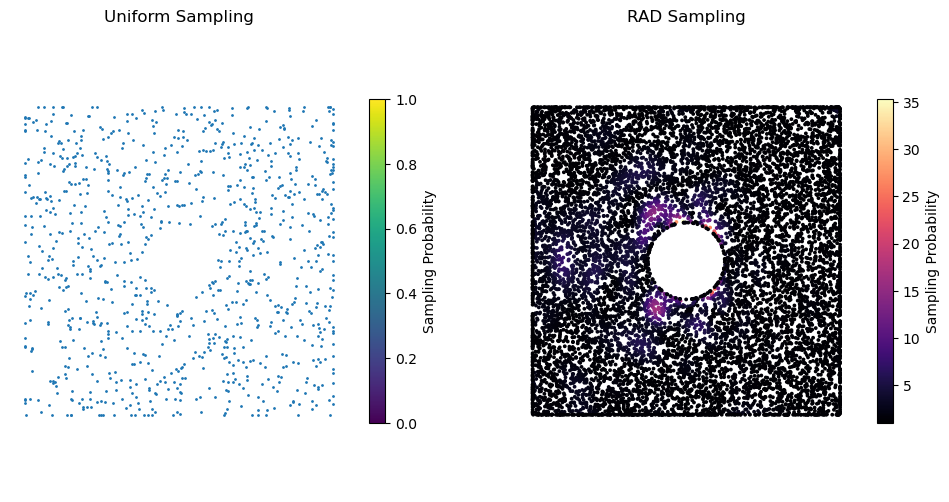

In [188]:
# Uniform sampling
ids_uniform = np.random.choice(len(X_all), size=N_new, replace=False)
X_uniform = X_all[ids_uniform]

plt.figure(figsize=(12,6))

# --- Uniform ---
plt.subplot(1,2,1)
#plt.scatter(X_all[:,0], X_all[:,1], c='lightgray', s=3)
plt.scatter(X_uniform[:,0], X_uniform[:,1], s=1)
plt.title("Uniform Sampling")
plt.axis("equal")
plt.colorbar(label="Sampling Probability", shrink=0.7)
plt.axis("off")
# --- RAD ---
plt.subplot(1,2,2)
plt.scatter(X_all[:,0], X_all[:,1], c=weights, s=3, cmap='magma')
#plt.scatter(X_rad[:,0], X_rad[:,1], color='black', s=1)
plt.title("RAD Sampling")
plt.axis("equal")
plt.axis("off")
plt.colorbar(label="Sampling Probability", shrink=0.7)
plt.show()